In [ ]:
import warnings

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import special_ortho_group
from scipy.special import erf
from pathlib import Path

# scipy's SO(n) sampler trips spurious FP flags under macOS Accelerate; the
# matrices it returns are orthonormal to ~1e-15, so the warnings are noise.
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)

FIG_DIR = Path("figures")


def generate_eigenvalues(ranges: list[tuple], nums: list, rng):
    groups = []
    for r, num in zip(ranges, nums):
        groups.append(rng.random(num) * (r[1] - r[0]) + r[0])
    return np.diag(np.concatenate(groups))


def random_rotation(d, rng):
    group = special_ortho_group(dim=d, seed=int(rng.integers(0, 10000)))
    return group.rvs(1)


def true_gradient(Q, theta, target):
    """True (noiseless) gradient ∇L(θ) = Q(θ − x*)"""
    return Q @ (theta - target)


def objective_loss(Q, theta, target):
    """True quadratic loss L(θ) = ½ (θ − x*)ᵀ Q (θ − x*)

    The constant ν²/2 tr(Q) offset of the sQP objective is dropped, as in Fig. 2
    of the paper (its panels descend below that offset).
    """
    diff = theta - target
    return 0.5 * np.dot(diff, Q @ diff)


def optimal_step_sgd(Q, true_grad, nu, tr_Q3):
    """
    Optimal local step size for the SGD direction z = −g.

    The paper (§3.1) minimises the *expected* loss E[L(θ + αz)], giving
        α* = −∇L(θ)ᵀ E[z] / E[zᵀQz].
    For z = −g with g ~ N(∇L, ν²QQ), E[gᵀQg] = ∇LᵀQ∇L + tr(Q cov[g]) and
    tr(Q ν²QQ) = ν² Σᵢ λᵢ³, so
        α* = ∇Lᵀ∇L / (∇LᵀQ∇L + ν² Σᵢ λᵢ³).
    Note this is deterministic given θ: it does *not* depend on the sampled
    gradient. At ν = 0 it reduces to the exact steepest-descent line search.
    """
    denom = np.dot(true_grad, Q @ true_grad) + nu ** 2 * tr_Q3
    return np.dot(true_grad, true_grad) / denom if denom > 1e-14 else 0.0


def optimal_step_ssd(Q, true_grad, nu, sigma, rng, n_mc=2000):
    """
    Optimal local step size for the SSD direction z = −sign(g), i.e.
        α* = ∇Lᵀ E[sign(g)] / E[sign(g)ᵀ Q sign(g)].

    Numerator in closed form: for gᵢ ~ N(∇Lᵢ, σᵢ²) with σᵢ² = ν² (QQ)ᵢᵢ,
        E[sign(gᵢ)] = (2ρᵢ − 1) sign(∇Lᵢ) = erf(|∇Lᵢ| / (√2 σᵢ)) sign(∇Lᵢ),
    so ∇Lᵀ E[sign(g)] = Σᵢ (2ρᵢ − 1) |∇Lᵢ|.

    The denominator needs E[sign(gᵢ)sign(gⱼ)] for a *correlated* Gaussian with
    non-zero means — orthant probabilities, with no elementary closed form once
    Q is non-diagonal. (§B.2 only bounds it, to bound I_SSD; the bound is far too
    loose to use as a step size.) We estimate E[ssᵀ] by Monte Carlo, pinning the
    diagonal to its exact value E[sᵢ²] = 1. This makes the estimate exact for
    axis-aligned Q and reduces variance elsewhere: α* lands within ~0.1% across
    seeds at n_mc = 2000.
    """
    if nu == 0:                                   # sign(g) is deterministic
        s = np.sign(true_grad)
        denom = np.dot(s, Q @ s)
        return np.dot(true_grad, s) / denom if denom > 1e-14 else 0.0

    numer = np.sum(np.abs(true_grad) * erf(np.abs(true_grad) / (np.sqrt(2) * sigma)))
    S = np.sign(true_grad - rng.normal(0.0, nu, size=(n_mc, len(true_grad))) @ Q)
    M = (S.T @ S) / n_mc
    np.fill_diagonal(M, 1.0)
    denom = np.sum(Q * M)
    return numer / denom if denom > 1e-14 else 0.0


def run_experiment(Q, target, nu, n_steps, rng, n_mc=2000):
    """
    Run SGD and SSD with their optimal local step sizes.
    Both methods see the same sequence of noise draws ε (they sit at different
    θ, so the gradients themselves still differ).
    """
    d = len(target)
    tr_Q3 = float(np.sum(np.linalg.eigvalsh(Q) ** 3))    # Σᵢ λᵢ³ = tr(QQQ)
    sigma = nu * np.sqrt(np.diag(Q @ Q))                 # per-coordinate grad std

    theta_sgd = np.zeros(d)
    theta_ssd = np.zeros(d)
    losses_sgd = [objective_loss(Q, theta_sgd, target)]
    losses_ssd = [objective_loss(Q, theta_ssd, target)]

    for _ in range(n_steps):
        eps = rng.normal(0.0, nu, size=d) if nu > 0 else np.zeros(d)

        # SGD: stochastic direction, deterministic (expected-optimal) step size
        tg = true_gradient(Q, theta_sgd, target)
        theta_sgd -= optimal_step_sgd(Q, tg, nu, tr_Q3) * (tg - Q @ eps)
        losses_sgd.append(objective_loss(Q, theta_sgd, target))

        # SSD
        tg = true_gradient(Q, theta_ssd, target)
        alpha = optimal_step_ssd(Q, tg, nu, sigma, rng, n_mc)
        theta_ssd -= alpha * np.sign(tg - Q @ eps)
        losses_ssd.append(objective_loss(Q, theta_ssd, target))

    return np.array(losses_sgd), np.array(losses_ssd)

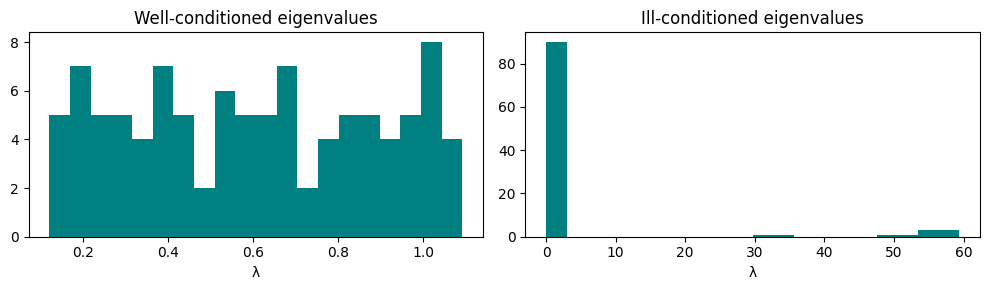

In [2]:
seed = 42
rng = np.random.default_rng(seed)

d = 100
n_steps = 100                  # matches the x-axis of Fig. 2
noise_levels = [0, 0.1, 4.0]   # ν values from the paper

# --- Minimiser x* -------------------------------------------------------------
# The paper does not state θ₀ or x*. Two things matter:
#  (1) x* must NOT be a multiple of the all-ones vector. With θ₀ = 0 and x* = 1
#      the initial error lies exactly along the sign-descent direction and every
#      coordinate is offset by the same amount, so SSD solves an axis-aligned
#      problem *exactly* in one line-searched step (α = 1). That is an artefact
#      of the initialisation, not a property of sign descent.
#  (2) The offset scale sets how much dynamic range lies above the noise floor.
#      The floor is fixed by ν, so with a small offset both methods start already
#      near it and the high-noise column is uninformative. Fig. 2 shows a long
#      descent *into* a plateau, which needs an offset of order 10 or more.
#      The paper's qualitative conclusions reproduce for any scale ≳ 10.
target = rng.uniform(-10.0, 10.0, size=d)

# --- Eigenvalue matrices (paper §3.2) ---
# (a) well-conditioned: λᵢ ~ Uniform[0.1, 1.1]
lamb1 = generate_eigenvalues([(0.1, 1.1)], [100], rng)
# (b) ill-conditioned: 90% from [0,1], 10% from [30,60]
lamb2 = generate_eigenvalues([(0, 1), (30, 60)], [90, 10], rng)

eig1 = np.diag(lamb1)
eig2 = np.diag(lamb2)

# --- Random rotation R drawn uniformly from SO(100) ---
R = random_rotation(d, rng)

# --- Four QP matrices, in the row order of Fig. 2 ---
qps = [
    (R @ lamb1 @ R.T, 'Well-conditioned, rotated'),
    (lamb1,           'Well-conditioned, axis-aligned'),
    (R @ lamb2 @ R.T, 'Ill-conditioned, rotated'),
    (lamb2,           'Ill-conditioned, axis-aligned'),
]

# Show eigenvalue spectra
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(eig1, bins=20, color='teal')
axes[0].set_title('Well-conditioned eigenvalues')
axes[0].set_xlabel('λ')
axes[1].hist(eig2, bins=20, color='teal')
axes[1].set_title('Ill-conditioned eigenvalues')
axes[1].set_xlabel('λ')
plt.tight_layout()
plt.show()

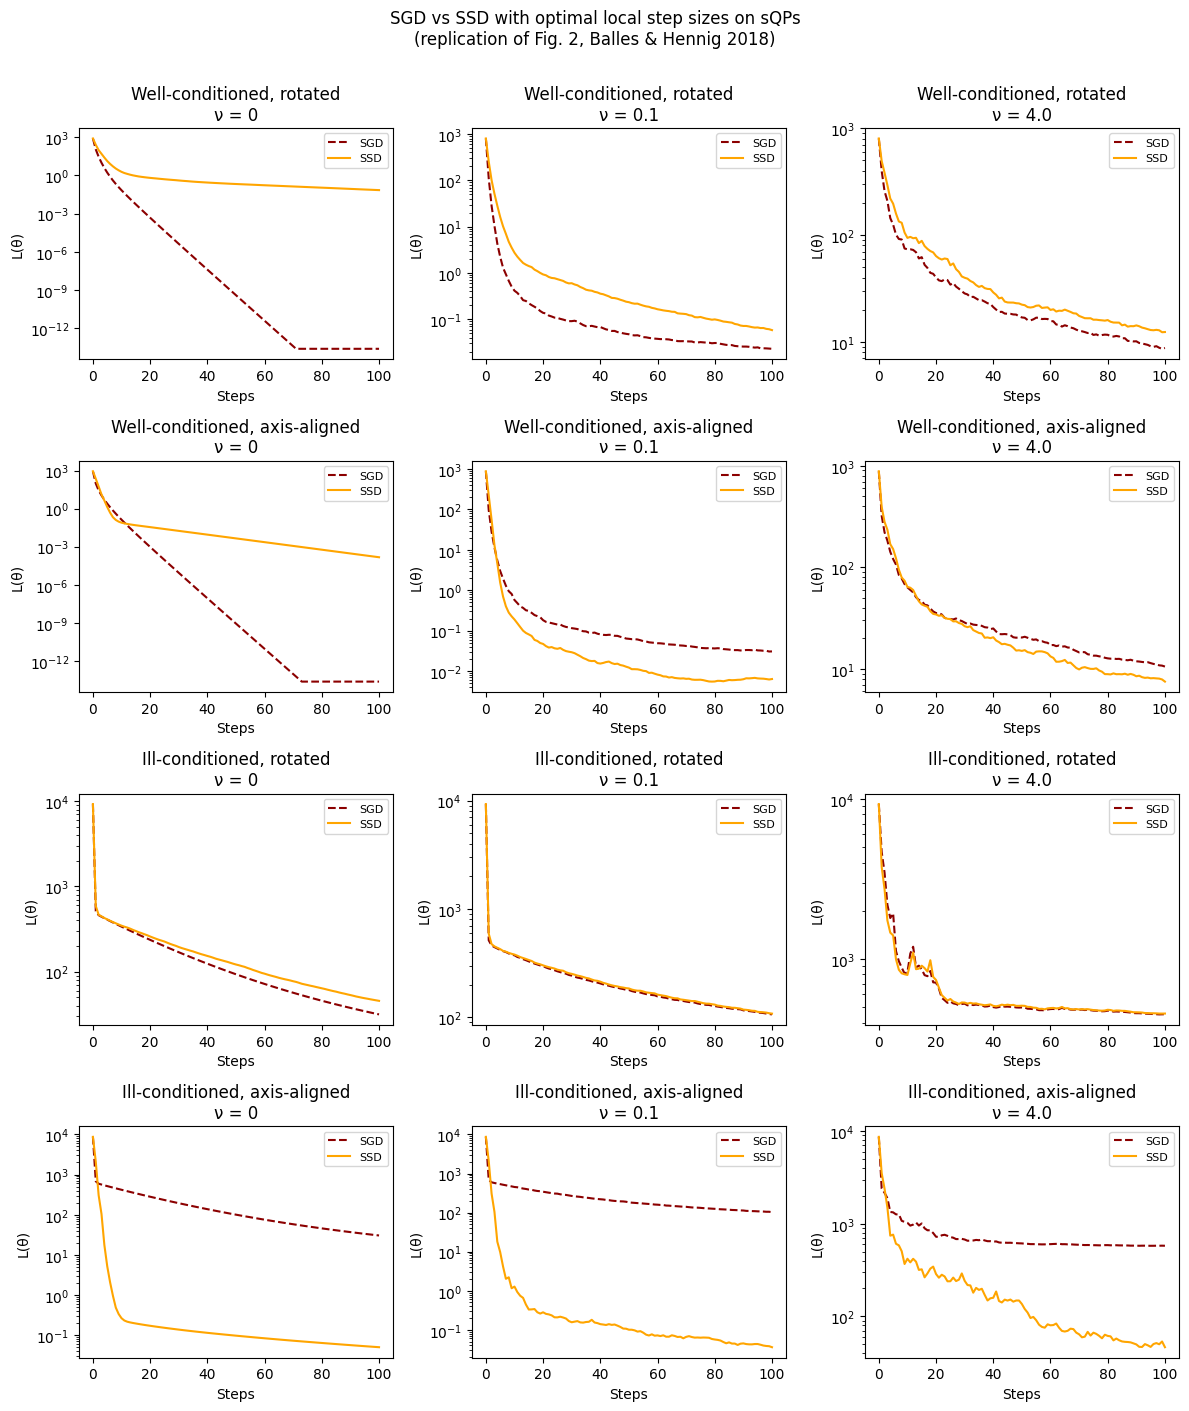

problem                              ν         SGD        SSD    SGD/SSD
Well-conditioned, rotated            0   2.365e-14  6.986e-02       0.00
Well-conditioned, rotated          0.1   2.301e-02  5.830e-02       0.39
Well-conditioned, rotated          4.0   8.776e+00  1.238e+01       0.71
Well-conditioned, axis-aligned       0   2.321e-14  1.473e-04       0.00
Well-conditioned, axis-aligned     0.1   3.068e-02  6.357e-03       4.83
Well-conditioned, axis-aligned     4.0   1.053e+01  7.489e+00       1.41
Ill-conditioned, rotated             0   3.153e+01  4.549e+01       0.69
Ill-conditioned, rotated           0.1   1.065e+02  1.083e+02       0.98
Ill-conditioned, rotated           4.0   4.504e+02  4.550e+02       0.99
Ill-conditioned, axis-aligned        0   3.042e+01  5.031e-02     604.60
Ill-conditioned, axis-aligned      0.1   1.023e+02  3.583e-02    2856.36
Ill-conditioned, axis-aligned      4.0   5.785e+02  4.643e+01      12.46


In [ ]:
steps = np.arange(n_steps + 1)
final = {}

fig, axes = plt.subplots(4, 3, figsize=(12, 14))

for row, (Q, label) in enumerate(qps):
    for col, nu in enumerate(noise_levels):
        rng_exp = np.random.default_rng(seed + row * 100 + col)
        losses_sgd, losses_ssd = run_experiment(Q, target, nu, n_steps, rng_exp)
        final[(label, nu)] = (losses_sgd[-1], losses_ssd[-1])

        ax = axes[row, col]
        ax.semilogy(steps, losses_sgd, color='darkred', linestyle='--', label='SGD')
        ax.semilogy(steps, losses_ssd, color='orange', label='SSD')
        ax.set_xlabel('Steps')
        ax.set_ylabel('L(θ)')
        ax.set_title(f'{label}\nν = {nu}')
        ax.legend(fontsize=8)

plt.suptitle(
    'SGD vs SSD with optimal local step sizes on sQPs\n'
    r'(replication of Fig. 2, Balles & Hennig 2018)',
    y=1.005
)
plt.tight_layout()
plt.savefig(FIG_DIR / 'toy_problem_replication.pdf', bbox_inches='tight')
plt.show()

print(f"{'problem':32s} {'ν':>5}  {'SGD':>10} {'SSD':>10}   {'SGD/SSD':>8}")
for (label, nu), (a, b) in final.items():
    print(f"{label:32s} {nu:5}  {a:10.3e} {b:10.3e}   {a / b:8.2f}")